In [1]:
import sys
from typing import Any, Dict, Optional
from pathlib import Path

import numpy as np

from SysSimX.core.base import CoSimComponent
from SysSimX.core.port import PortSpec, PortType
from SysSimX.core.events import EventLocator, Event

from SysSimX.system.connection import EventConnection
from SysSimX.system.system import System

from SysSimX.components.fmu_comp import FMUComponent

from SysSimX.utilities.units import Quantity

from SysSimX.viz.sysgraph import SystemGraphVisualizer

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import docs.plot_setup as plot_setup
plt = plot_setup.set_professional_style()

In [2]:
class HybridSource(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = -1.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Sources')
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x", 
                                                type=PortType.REAL,
                                                direction="out")})
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
    
    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot) -> None:
        self.t  = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x  = snapshot["x"]
        self.v  = snapshot["v"]

class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})             
    
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _handle_events_internal(self, event_names, t):
        if 'Trigger_1' in event_names or 'Trigger_2' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v

In [3]:
class HybridSource(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group='Sources')
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({
            "x": PortSpec(name="x", 
                          type=PortType.REAL,
                          direction="out"),
        })
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    
    def snapshot_state(self):
        return {"t": self.t, "x": self.x, "v": self.v, "t0": self.t0}

    def restore_state(self, snapshot) -> None:
        self.t  = snapshot["t"]
        self.t0 = snapshot["t0"]
        self.x  = snapshot["x"]
        self.v  = snapshot["v"]
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self.inputs.clear()
        self.outputs.clear()

In [4]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})             
    
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)

    def _handle_events_internal(self, event_names, t):
        if 'Trigger_1' in event_names or 'Trigger_2' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")

In [5]:
class HybridListener(CoSimComponent):
    """
    Simple component with a state variable that evolves linearly.
    x(t) = x0 + v * (t - t0)    
    """
    def __init__(self, name: str, x0: float = 0.0, v: float = 1.0, t0: float = 0.0):
        super().__init__(name, group="Listener")
        self.x0 = x0; self.v = v; self.t0 = t0
        
    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.output_specs.update({"x": PortSpec(name="x",
                                                type=PortType.REAL,
                                                direction="out")})
        self.input_specs.update({"v_invert": PortSpec(name="v_invert",
                                                      type=PortType.EVENT,
                                                      direction="in")})  
        self._initialize_ports_from_specs()
        
    def _do_step_internal(self, t: float, dt: float) -> None:
        self.x = self.x0 + self.v * (t + dt - self.t0)
        
    def _update_output_states(self, t: Optional[float]=None) -> None:
        self.outputs["x"].set(self.x, t=t)
        
    def set_state(self, state: Dict[str, Any], t: float) -> None:
        if "x" in state:
            val = state["x"]
            self.x = val.magnitude if isinstance(val, Quantity) else val
            
    def get_state(self) -> Dict[str, Any]:
        return {"x": self.x}
    

    def _handle_events_internal(self, event_names, t):
        if 'Trigger_1' in event_names or 'Trigger_2' in event_names:
            self.t0 = t
            self.x0 = self.x
            self.v = -self.v
            print(f"{self.name} handled event at t={t:.4f}: v inverted from { -self.v } to { self.v }")
    
    def reset(self) -> None:
        super().reset()
        self.x = self.x0
        self._t0 = None
        self.inputs = {}
        self.outputs = {}


Component Classification:
 - event_sources: ['Source_1', 'Source_2']
 - event_listeners: ['Listener']
 - continuous_only: []

Using Algorithm: Hybrid-Algorithm



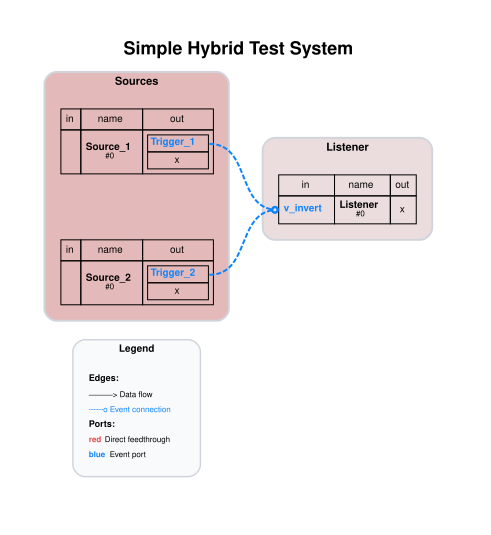

Starting hybrid co-simulation...

Event(s) detected in interval [0.30000000, 0.35000000]
Located at t=0.33333334
Events: [('Source_1', 'Trigger_1')]
Dispatching event 'Trigger_1' from 'Source_1' to targets: ['Listener']
Listener handled event at t=0.3333: v inverted from 3.0 to -3.0

Event(s) detected in interval [0.65000000, 0.70000000]
Located at t=0.66666667
Events: [('Source_2', 'Trigger_2')]
Dispatching event 'Trigger_2' from 'Source_2' to targets: ['Listener']
Listener handled event at t=0.6667: v inverted from -3.0 to 3.0



In [6]:
# 1) Create components
src_comp_1 = HybridSource(name="Source_1", x0=-2/3, v=2)
src_comp_2 = HybridSource(name="Source_2", x0=2/3,  v=-1)
listener_comp = HybridListener(name="Listener", x0=0.0,  v=3.0)

# 2) Define event indicator functions
def event_indicator_function(comp: HybridSource) -> float:
    return comp.x

# 3) Create events
event_1 = Event(name="Trigger_1", source=src_comp_1.name, direction=1)
event_2 = Event(name="Trigger_2", source=src_comp_2.name, direction=-1)

# 4) Initialize event source components
src_comp_1.initialize(t0=0.0)
src_comp_2.initialize(t0=0.0)

# 5) Add event indicators to source components
src_comp_1.add_event_indicator(name=event_1.name,
                               func=event_indicator_function,
                               direction=event_1.direction)
src_comp_2.add_event_indicator(name=event_2.name,
                               func=event_indicator_function,
                               direction=event_2.direction)

# 6) Initialize listener component and subscribe to events
listener_comp.initialize(t0=0.0)
listener_comp.subscribe_event(event=event_1)
listener_comp.subscribe_event(event=event_2)

# 7) Create system
system = System(name="Simple Hybrid Test System")

# 8) Add components to system
system.add_component(src_comp_1)
system.add_component(src_comp_2)
system.add_component(listener_comp)

# 9) Create and add event connections to the system
connection_1 = EventConnection(src_comp=src_comp_1.name,
                               src_port=src_comp_1.output_specs['Trigger_1'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)
connection_2 = EventConnection(src_comp=src_comp_2.name,
                               src_port=src_comp_2.output_specs['Trigger_2'].name,
                               dst_comp=listener_comp.name,
                               dst_port=listener_comp.input_specs['v_invert'].name)
system.add_event_connection(connection_1)
system.add_event_connection(connection_2)

# 10) Initialize the system
system.initialize(t0=0.0)

# 11) Component classification
print("\nComponent Classification:")
for classification, components in system.classify_components().items():
    print(f" - {classification}: {[component.name for component in components]}")

print(f"\nUsing Algorithm: {system.algorithm.name}\n")

# 11) Visualize the system graph
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

# 12) Run the simulation
print("Starting hybrid co-simulation...\n")
system.run(t0=0.0, tf=1.0, dt = 0.05)

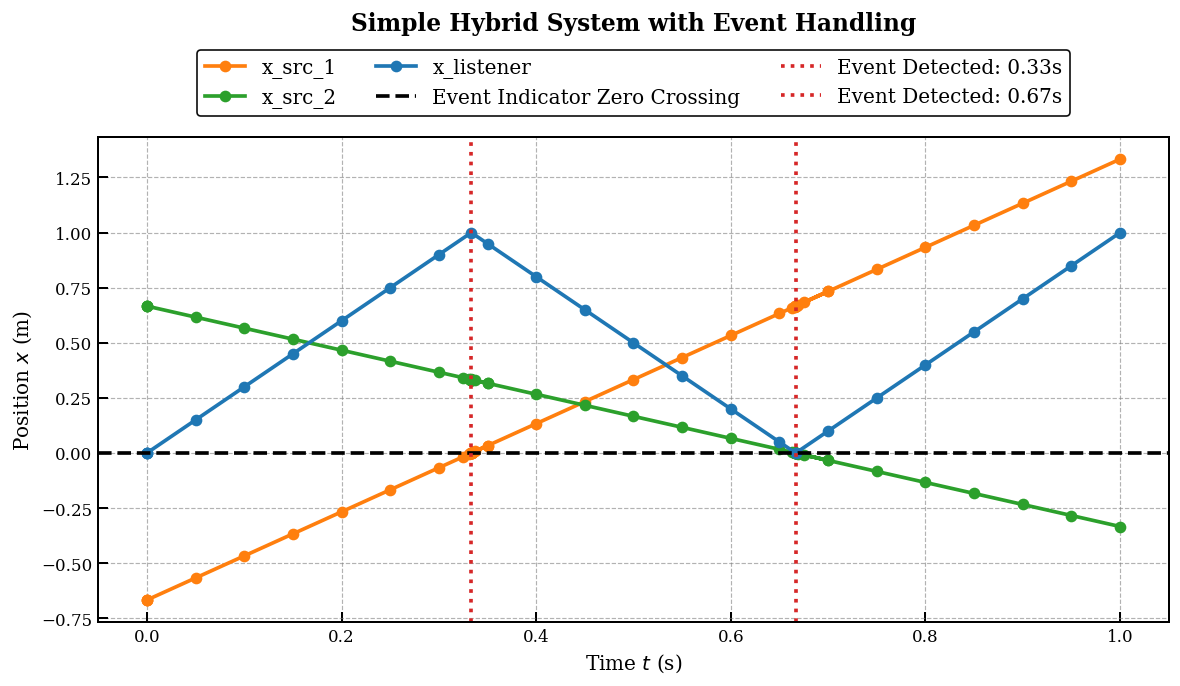

In [7]:
time_src_1, data_src_1 = src_comp_1.get_history_arrays()
x_src_1 = data_src_1['x']

time_src_2, data_src_2 = src_comp_2.get_history_arrays()
x_src_2 = data_src_2['x']

time_listener, data_listener = listener_comp.get_history_arrays()
x_listener = data_listener['x']

plt.figure(figsize=(10, 6))
plt.plot(time_src_1, x_src_1, label='x_src_1', color='tab:orange', marker='o', linestyle='-')
plt.plot(time_src_2, x_src_2, label='x_src_2', color='tab:green', marker='o', linestyle='-')
plt.plot(time_listener, x_listener, label='x_listener', color='tab:blue', marker='o', linestyle='-')
plt.axhline(0, color='black', linestyle='--', label='Event Indicator Zero Crossing')

for key, array in system.history.get_all_event_histories().items():
    for event_time in array:
        plt.axvline(event_time, color='tab:red', linestyle=':', label=f'Event Detected: {event_time:.2f}s')

plt.title('Simple Hybrid System with Event Handling', fontsize=14, fontweight='bold', y= 1.2)
plt.xlabel('Time $t$ (s)')
plt.ylabel('Position $x$ (m)')
plt.grid()
plt.legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.2))
plt.tight_layout()
plt.savefig('../figures/Hybrid/test_5_event_handling.svg')
plt.show()

-------------------

## Recommendations for Improved Testing

### Fix Component Implementations:
1. **HybridSource** - Include `_t0` and `x0` in snapshot/restore
2. **HybridListener** - Store `self.x0 = x0` in `__init__`

### Additional Test Cases Needed:
1. **Multiple events**: Test with 2+ zero crossings in one simulation
2. **Simultaneous events**: Two components with events at same time
3. **Data coupling**: Connect source output to listener input to test frozen inputs
4. **Algebraic loops**: Add components with algebraic coupling + events
5. **Event frequency**: Test events in quick succession (stress test bisection)
6. **Edge cases**: Event exactly at t=0, t=tf, or on step boundaries